## Bethe-Bloch Simulation

In [ ]:
import numpy as np
import scipy.constants as con

def beta(T: float, E_0: float):
    """
    :T: Kinetische Energie des Teilchens in eV
    :E_0: Ruheenergie des Teilchens in eV
    """
    gamma = (T/E_0)+1
    return np.sqrt(1-1/gamma**2)

class Material:
    def __init__(self, Z, A, I, n):
        """
        :Z: Ladungszahl
        :A: Massenzahl
        :I: mittlere Ionisationsenergy (in J)
        :n: Dichte in g/cm³
        """
        self.I = I
        self.n_e = Z*n*1e3/A/con.u

Au = Material(79, 197, 790*con.e, 19.32)
Si = Material(14, 28, 173*con.e, 2.33)

def Bethe(target: Material, E:float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    b =(con.e**2/(4*np.pi*con.epsilon_0))**2
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return -a * b * c

def Reichweite(target: Material, E: float, dx=1e-6, Elim=1):
    """
    :target: Materialeigenschaften des Zielmaterials
    :E: Kinetische Energie des Teilchens in eV
    :dx: Schrittweite in m
    """
    l = 0
    while E > Elim: # in eV
        lost = Bethe(target, E) / con.e * dx # Energieverlust in eV
        E -= abs(lost)
        l += dx
    return l

In [2]:
E = np.logspace(4, 8, endpoint=True)

vBethe = np.vectorize(Bethe)
vReich = np.vectorize(Reichweite)

dEdx = vBethe(Si, E)
rw = vReich(Si, E, dx=1e-6)

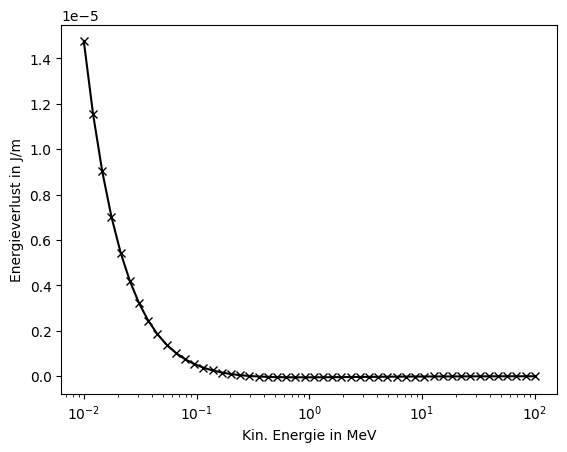

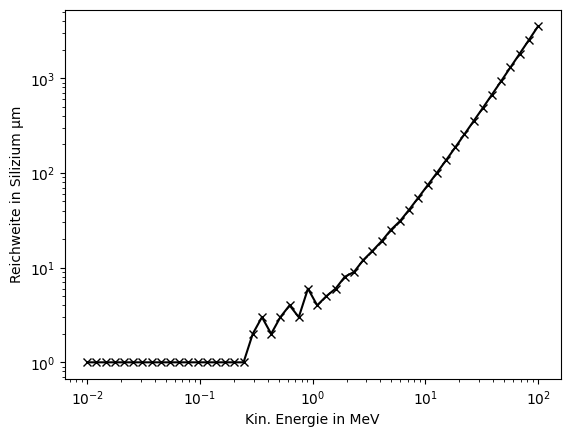

In [3]:
import matplotlib.pyplot as plt

plt.plot(E/1e6, dEdx, 'x-k')
plt.xscale('log')
plt.ylabel('Energieverlust in J/m')
plt.xlabel('Kin. Energie in MeV')

fig, ax = plt.subplots()
ax.plot(E/1e6, rw/1e-6, 'x-k')


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Kin. Energie in MeV')
ax.set_ylabel('Reichweite in Silizium µm')


plt.show()

## Linearitätsprüfung

In [ ]:
import pandas as pd



## $\alpha$-Spektrum fits